# Standard Support Vector Machine (SVM) - Cancer Risk Dataset

This notebook trains a standard (non-private) SVM classifier on the Cancer Risk dataset to establish baseline performance.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"\nFeatures: {feature_names}")

Training data shape: (1200, 8)
Test data shape: (300, 8)
Number of features: 8

Features: ['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory']


## 3. Train Standard SVM

In [3]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

print("Training Standard SVM...")
_t0 = time.perf_counter()
svm_model.fit(X_train, y_train)
train_time = time.perf_counter() - _t0
# Score the non-private fit on the training partition too, so the
# generalisation gap can be read next to the held-out metrics.
y_train_pred = svm_model.predict(X_train)
print("Training complete!")

Training Standard SVM...
Training complete!


In [4]:
# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model

export_model(svm_model, 'output/model/std_svm_model.pkl')

Model successfully exported to output/model/std_svm_model.pkl


## 4. Model Evaluation

In [5]:
y_pred = svm_model.predict(X_test)

extra = ExtraMetrics()
accuracy = accuracy_score(y_test, y_pred)
extra.add(y_test, y_pred, model=svm_model, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("="*60)
print("STANDARD SVM - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("="*60)

STANDARD SVM - PERFORMANCE METRICS
Accuracy:  0.8833
F1-Score:  0.8357
Precision: 0.8725
Recall:    0.8018


## 5. Confusion Matrix

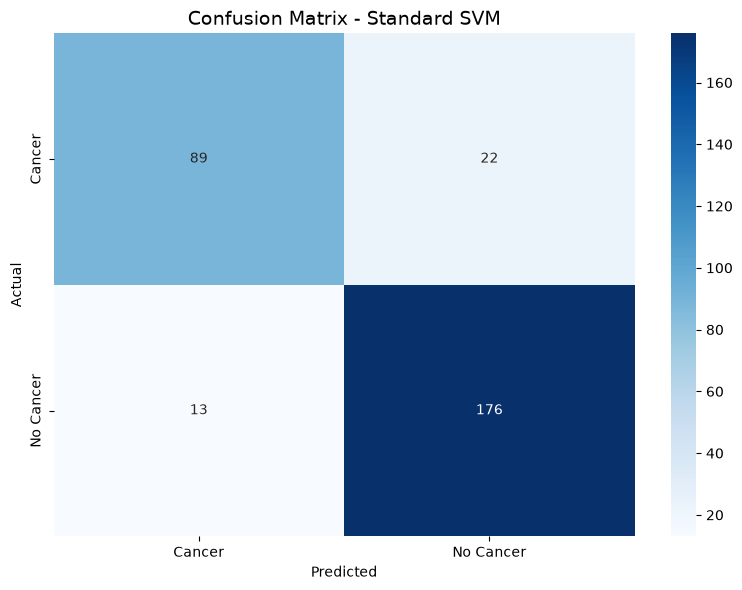

In [6]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
custom_cm = np.array([[TP, FN], [FP, TN]])

plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cancer', 'No Cancer'],
            yticklabels=['Cancer', 'No Cancer'])
plt.title('Confusion Matrix - Standard SVM', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 6. Classification Report

In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Cancer', 'Cancer']))

Classification Report:
              precision    recall  f1-score   support

   No Cancer       0.89      0.93      0.91       189
      Cancer       0.87      0.80      0.84       111

    accuracy                           0.88       300
   macro avg       0.88      0.87      0.87       300
weighted avg       0.88      0.88      0.88       300



## 7. Save Baseline Results

In [8]:
import os
os.makedirs('output', exist_ok=True)

baseline_results = pd.DataFrame({
    'model': ['Standard_SVM'],
    'accuracy': [accuracy],
    'f1_score': [f1],
    'precision': [precision],
    'recall': [recall]
})
baseline_results.to_csv('output/baseline_results.csv', index=False)
print("Baseline results saved to 'output/baseline_results.csv'")

report = {
    'model_type': 'Standard SVM',
    'dataset': 'Cancer Risk Prediction',
    'parameters': {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale', 'random_state': 42},
    'metrics': {'accuracy': float(accuracy), 'f1_score': float(f1), 'precision': float(precision), 'recall': float(recall)},
    'confusion_matrix': custom_cm.tolist()
}
report.update(extra.means())
with open('output/std_svm_report.json', 'w') as f:
    json.dump(report, f, indent=4)
print("Detailed report saved to 'output/std_svm_report.json'")

print("Added metrics:")
print(extra.describe())

Baseline results saved to 'output/baseline_results.csv'
Detailed report saved to 'output/std_svm_report.json'
Added metrics:
  Train Acc:      0.8908 ± 0.0000
  Balanced Acc:   0.8665 ± 0.0000
  AUROC:          0.9405 ± 0.0000
  Train Time (s): 0.0357 ± 0.0000


## 8. Summary

In [9]:
print("\n" + "="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)
print(f"Model: Standard SVM (RBF kernel)")
print(f"Dataset: Cancer Risk Prediction ({X_train.shape[0]:,} train, {X_test.shape[0]:,} test)")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"\nBaseline established for DP comparison")
print("="*60)


BASELINE MODEL SUMMARY
Model: Standard SVM (RBF kernel)
Dataset: Cancer Risk Prediction (1,200 train, 300 test)

Performance Metrics:
  Accuracy:  0.8833
  F1-Score:  0.8357
  Precision: 0.8725
  Recall:    0.8018

Baseline established for DP comparison
